# 1. Matplotlib foundations for data and language research

This notebook continues from the basic pandas plot in Stage 3 and introduces the object-oriented Matplotlib workflow.  
It uses small **synthetic language-research datasets** and emphasizes patterns that transfer to corpus linguistics and NLP.

## Learning objectives

By the end, you should be able to:

- understand the `Figure`–`Axes` object model;
- create line, bar, scatter, histogram, box, and pie/donut charts;
- build grouped charts and multi-panel figures;
- label, annotate, format, and export figures;
- choose readable, accessible visual encodings;
- avoid common plotting mistakes.

> All datasets in this notebook are synthetic and are used only for teaching.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Matplotlib:", matplotlib.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

RNG = np.random.default_rng(42)

# A clean default for notebooks. Individual figures can still override these settings.
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
})

Matplotlib: 3.10.8
NumPy: 2.3.5
pandas: 2.2.3


## 1. The object-oriented interface

Matplotlib has two common interfaces:

1. **Stateful `pyplot`** calls such as `plt.plot(...)`;
2. **Object-oriented** calls using explicit `Figure` and `Axes` objects.

For reusable research code, prefer:

```python
fig, ax = plt.subplots()
ax.plot(...)
ax.set(...)
```

The `Figure` is the whole canvas. An `Axes` is one plotting region inside that canvas.

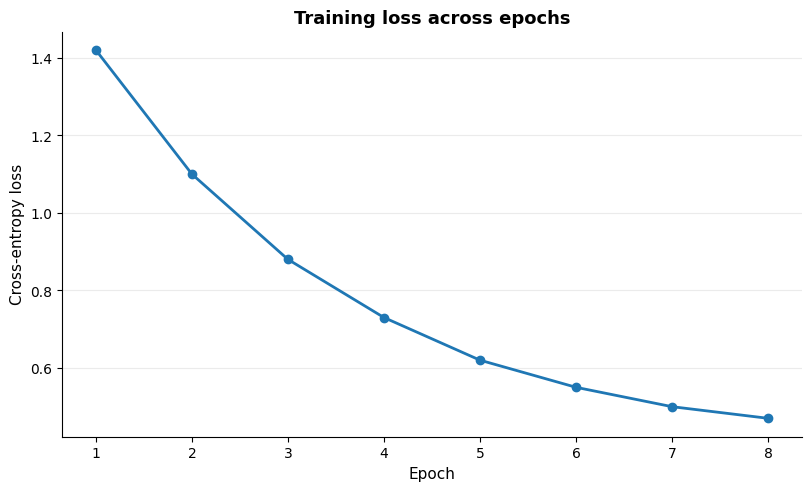

In [2]:
epochs = np.arange(1, 9)
training_loss = np.array([1.42, 1.10, 0.88, 0.73, 0.62, 0.55, 0.50, 0.47])

fig, ax = plt.subplots(layout="constrained")
ax.plot(epochs, training_loss, marker="o", linewidth=2)
ax.set(
    title="Training loss across epochs",
    xlabel="Epoch",
    ylabel="Cross-entropy loss",
    xticks=epochs,
)
ax.grid(axis="y", alpha=0.25)
plt.show()

### Why keep explicit plot objects?

Explicit `fig` and `ax` objects make it easier to:

- add annotations;
- create multiple panels;
- control legends and labels;
- save the correct figure;
- wrap plotting code inside functions.

## 2. Multiple series and meaningful legends

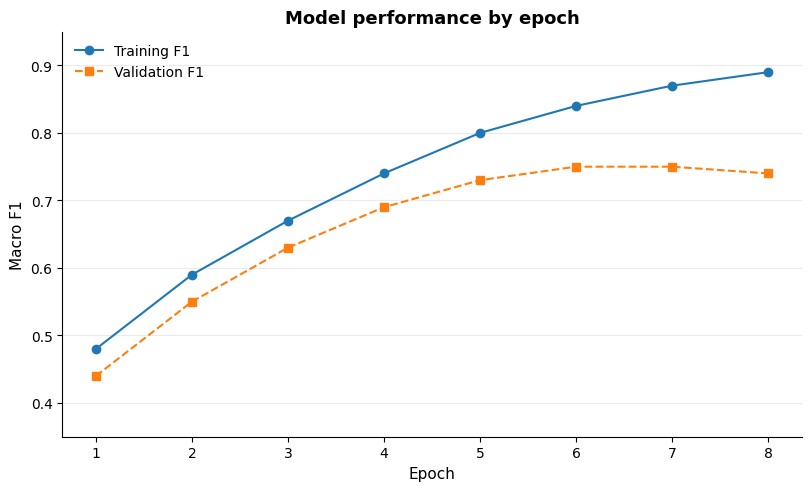

In [3]:
train_f1 = np.array([0.48, 0.59, 0.67, 0.74, 0.80, 0.84, 0.87, 0.89])
valid_f1 = np.array([0.44, 0.55, 0.63, 0.69, 0.73, 0.75, 0.75, 0.74])

fig, ax = plt.subplots(layout="constrained")
ax.plot(epochs, train_f1, marker="o", label="Training F1")
ax.plot(epochs, valid_f1, marker="s", linestyle="--", label="Validation F1")
ax.set(
    title="Model performance by epoch",
    xlabel="Epoch",
    ylabel="Macro F1",
    ylim=(0.35, 0.95),
    xticks=epochs,
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()

Use line charts when the horizontal axis has an inherent order, such as time, epochs, corpus size, or threshold values.  
Do not connect unrelated categories with a line.

## 3. Bar charts: categorical comparisons

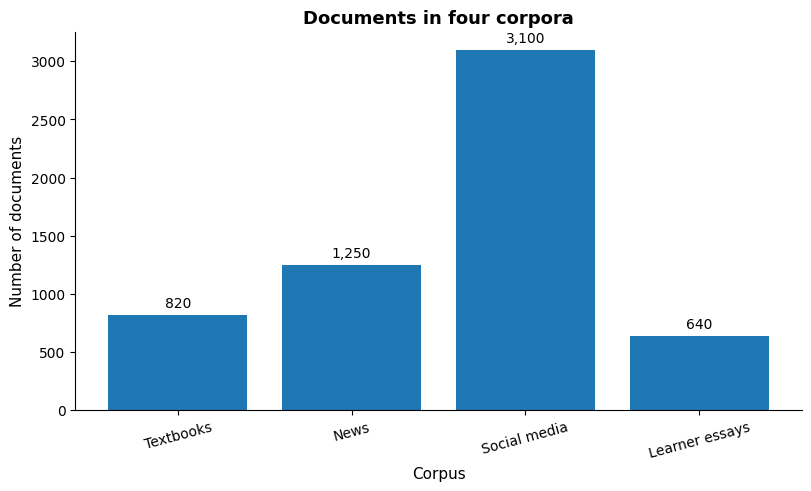

In [4]:
corpora = ["Textbooks", "News", "Social media", "Learner essays"]
documents = np.array([820, 1250, 3100, 640])

fig, ax = plt.subplots(layout="constrained")
bars = ax.bar(corpora, documents)
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.set(
    title="Documents in four corpora",
    xlabel="Corpus",
    ylabel="Number of documents",
)
ax.tick_params(axis="x", rotation=15)
plt.show()

### Horizontal bars for long labels

Horizontal bars are often easier to read when category labels are long—a frequent situation with linguistic tag names.

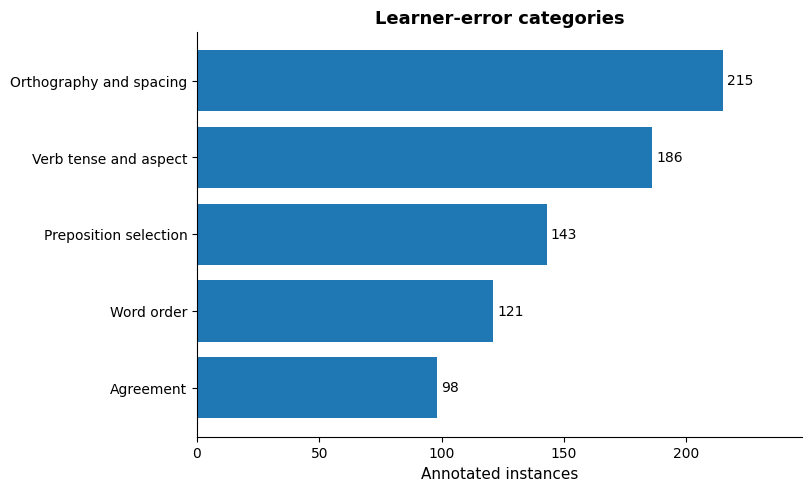

In [5]:
error_types = pd.Series({
    "Verb tense and aspect": 186,
    "Preposition selection": 143,
    "Word order": 121,
    "Agreement": 98,
    "Orthography and spacing": 215,
}).sort_values()

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(error_types.index, error_types.values)
ax.bar_label(bars, padding=3)
ax.set(
    title="Learner-error categories",
    xlabel="Annotated instances",
    ylabel="",
)
ax.set_xlim(0, error_types.max() * 1.15)
plt.show()

## 4. Grouped bars—without overlap

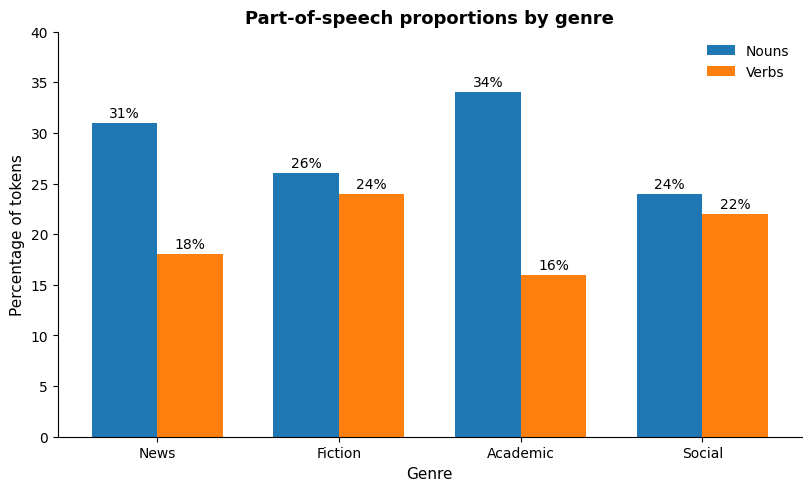

In [6]:
genres = ["News", "Fiction", "Academic", "Social"]
noun_pct = np.array([31, 26, 34, 24])
verb_pct = np.array([18, 24, 16, 22])

x = np.arange(len(genres))
width = 0.36

fig, ax = plt.subplots(layout="constrained")
noun_bars = ax.bar(x - width / 2, noun_pct, width, label="Nouns")
verb_bars = ax.bar(x + width / 2, verb_pct, width, label="Verbs")

ax.bar_label(noun_bars, padding=2, fmt="%.0f%%")
ax.bar_label(verb_bars, padding=2, fmt="%.0f%%")
ax.set(
    title="Part-of-speech proportions by genre",
    xlabel="Genre",
    ylabel="Percentage of tokens",
    xticks=x,
    xticklabels=genres,
    ylim=(0, 40),
)
ax.legend()
plt.show()

Define `width` once and offset each series around the category center. This prevents grouped bars from overlapping.

## 5. Stacked bars for composition

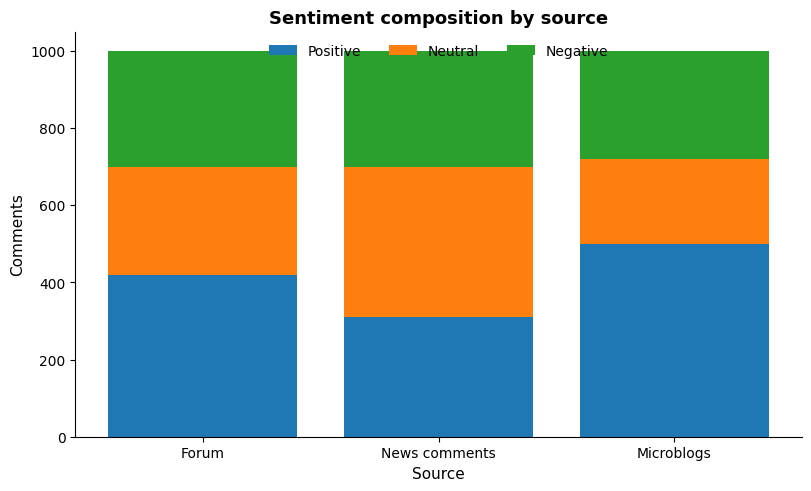

In [7]:
labels = ["Positive", "Neutral", "Negative"]
platform_a = np.array([420, 280, 300])
platform_b = np.array([310, 390, 300])
platform_c = np.array([500, 220, 280])

platforms = ["Forum", "News comments", "Microblogs"]
values = np.vstack([platform_a, platform_b, platform_c])
bottom = np.zeros(len(platforms))

fig, ax = plt.subplots(layout="constrained")
for i, label in enumerate(labels):
    ax.bar(platforms, values[:, i], bottom=bottom, label=label)
    bottom += values[:, i]

ax.set(
    title="Sentiment composition by source",
    xlabel="Source",
    ylabel="Comments",
)
ax.legend(ncols=3, loc="upper center")
plt.show()

Stacked bars show composition, but comparisons away from the common baseline are difficult.  
Use grouped bars when precise cross-category comparison matters.

## 6. Histograms: distributions, not categories

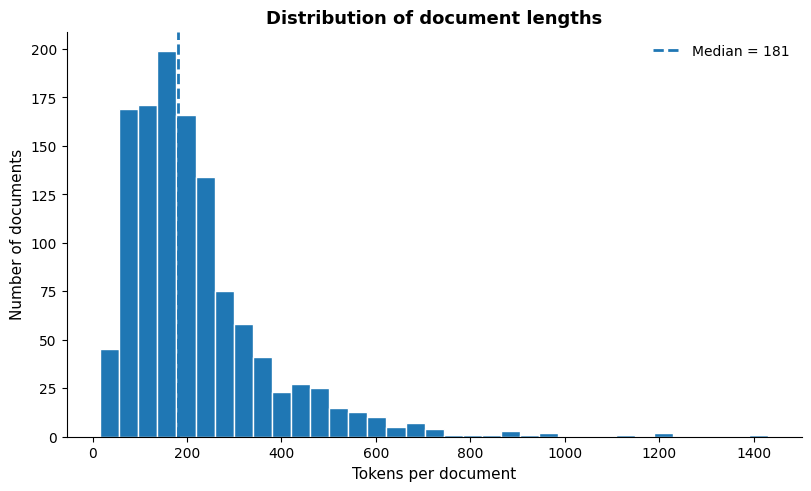

In [8]:
doc_lengths = RNG.lognormal(mean=5.2, sigma=0.65, size=1200).astype(int)

fig, ax = plt.subplots(layout="constrained")
ax.hist(doc_lengths, bins=35, edgecolor="white")
ax.axvline(np.median(doc_lengths), linestyle="--", linewidth=2,
           label=f"Median = {np.median(doc_lengths):.0f}")
ax.set(
    title="Distribution of document lengths",
    xlabel="Tokens per document",
    ylabel="Number of documents",
)
ax.legend()
plt.show()

Histogram appearance depends on bin width. Try several reasonable bin counts and report the choice in reproducible research.

## 7. Box plots and violin plots

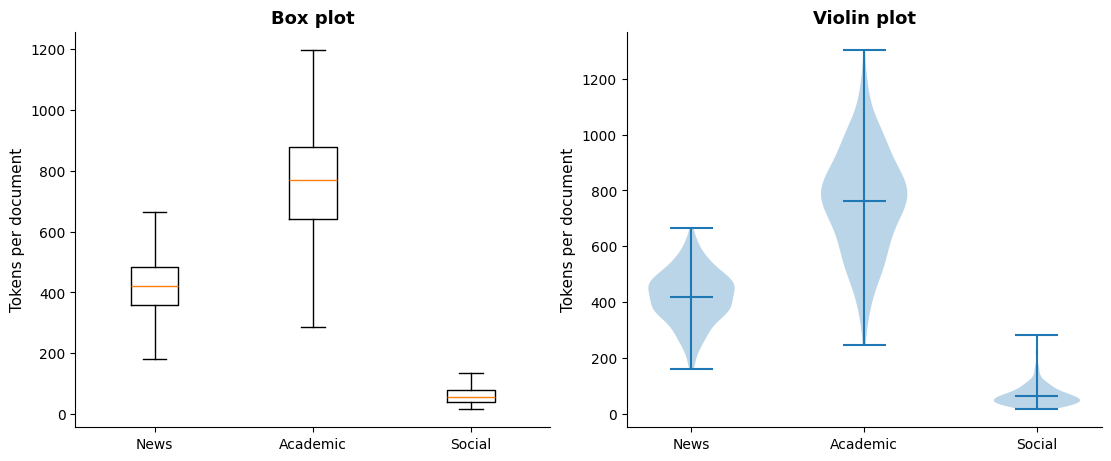

In [9]:
length_data = pd.DataFrame({
    "News": RNG.normal(420, 90, 220).clip(80),
    "Academic": RNG.normal(780, 180, 220).clip(120),
    "Social": RNG.lognormal(4.1, 0.55, 220),
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")

axes[0].boxplot(length_data.values, tick_labels=length_data.columns, showfliers=False)
axes[0].set(title="Box plot", ylabel="Tokens per document")

axes[1].violinplot(
    [length_data[c].values for c in length_data.columns],
    showmeans=True,
    showextrema=True,
)
axes[1].set(
    title="Violin plot",
    ylabel="Tokens per document",
    xticks=np.arange(1, len(length_data.columns) + 1),
    xticklabels=length_data.columns,
)

plt.show()

Box plots summarize medians and quartiles. Violin plots add an estimate of distribution shape.  
Use violin plots carefully with small samples because the smooth shape can imply more certainty than the data support.

## 8. Scatterplots: relationships between numerical variables

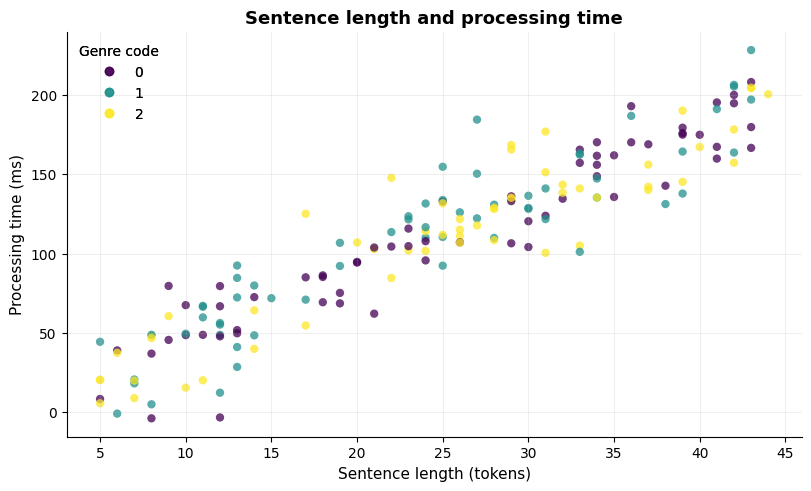

In [10]:
sentence_length = RNG.integers(5, 45, size=180)
processing_time_ms = 4.5 * sentence_length + RNG.normal(0, 22, size=180)
genre_id = RNG.integers(0, 3, size=180)

fig, ax = plt.subplots(layout="constrained")
scatter = ax.scatter(
    sentence_length,
    processing_time_ms,
    c=genre_id,
    cmap="viridis",
    alpha=0.75,
    edgecolors="none",
)
ax.set(
    title="Sentence length and processing time",
    xlabel="Sentence length (tokens)",
    ylabel="Processing time (ms)",
)
legend = ax.legend(*scatter.legend_elements(), title="Genre code")
ax.add_artist(legend)
ax.grid(alpha=0.2)
plt.show()

Color can encode a third variable, while marker size can encode a fourth. Avoid adding dimensions unless they answer a research question.

## 9. Annotations and reference lines

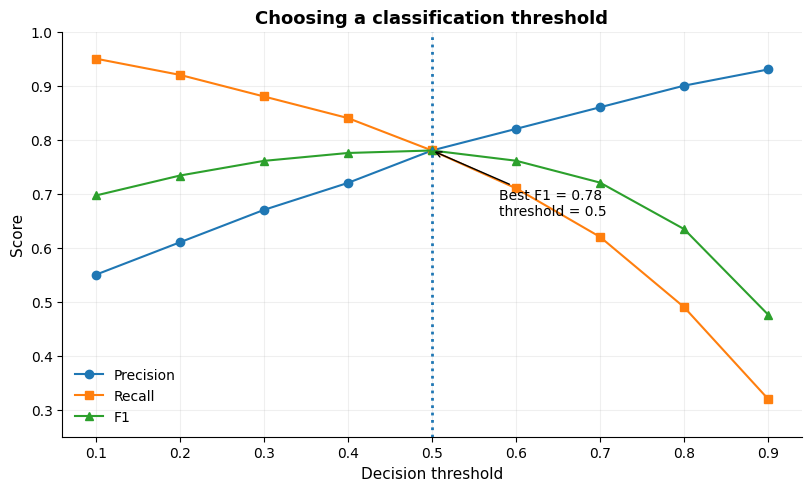

In [11]:
thresholds = np.linspace(0.1, 0.9, 9)
precision = np.array([0.55, 0.61, 0.67, 0.72, 0.78, 0.82, 0.86, 0.90, 0.93])
recall = np.array([0.95, 0.92, 0.88, 0.84, 0.78, 0.71, 0.62, 0.49, 0.32])
f1 = 2 * precision * recall / (precision + recall)
best = int(np.argmax(f1))

fig, ax = plt.subplots(layout="constrained")
ax.plot(thresholds, precision, marker="o", label="Precision")
ax.plot(thresholds, recall, marker="s", label="Recall")
ax.plot(thresholds, f1, marker="^", label="F1")
ax.axvline(thresholds[best], linestyle=":", linewidth=2)
ax.annotate(
    f"Best F1 = {f1[best]:.2f}\nthreshold = {thresholds[best]:.1f}",
    xy=(thresholds[best], f1[best]),
    xytext=(thresholds[best] + 0.08, f1[best] - 0.12),
    arrowprops={"arrowstyle": "->"},
)
ax.set(
    title="Choosing a classification threshold",
    xlabel="Decision threshold",
    ylabel="Score",
    ylim=(0.25, 1.0),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 10. Multi-panel figures

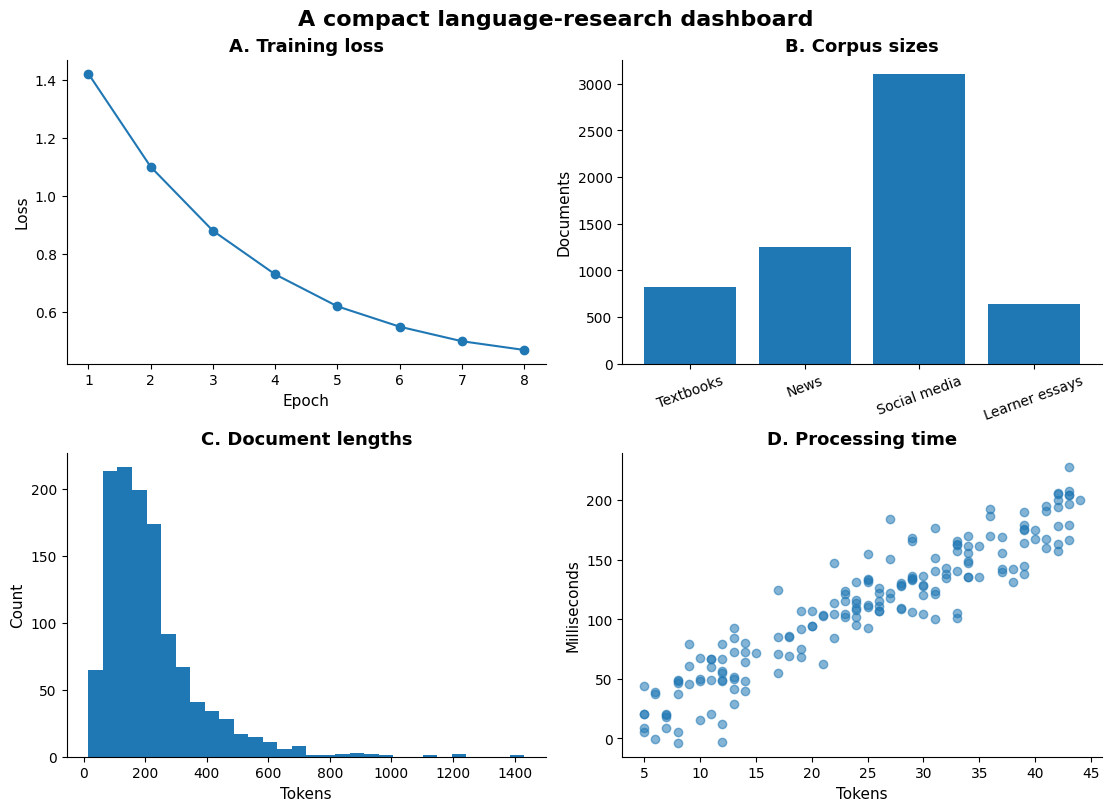

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), layout="constrained")

axes[0, 0].plot(epochs, training_loss, marker="o")
axes[0, 0].set(title="A. Training loss", xlabel="Epoch", ylabel="Loss")

axes[0, 1].bar(corpora, documents)
axes[0, 1].set(title="B. Corpus sizes", ylabel="Documents")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].hist(doc_lengths, bins=30)
axes[1, 0].set(title="C. Document lengths", xlabel="Tokens", ylabel="Count")

axes[1, 1].scatter(sentence_length, processing_time_ms, alpha=0.55)
axes[1, 1].set(title="D. Processing time", xlabel="Tokens", ylabel="Milliseconds")

fig.suptitle("A compact language-research dashboard", fontsize=16, fontweight="bold")
plt.show()

Use panels when the plots belong to one argument. Give panels a consistent scale and explicit labels such as A, B, C, and D.

## 11. Logarithmic scales

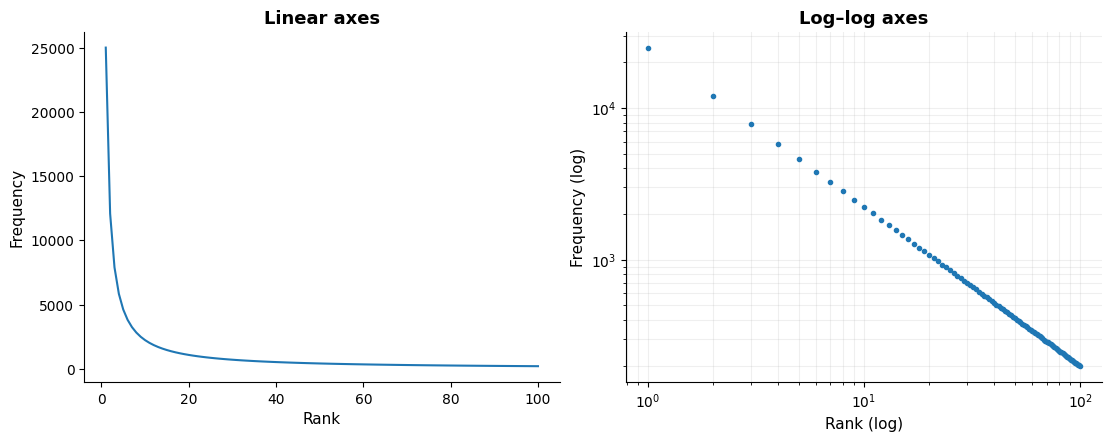

In [13]:
ranks = np.arange(1, 101)
frequency = 25000 / (ranks ** 1.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), layout="constrained")

axes[0].plot(ranks, frequency)
axes[0].set(title="Linear axes", xlabel="Rank", ylabel="Frequency")

axes[1].loglog(ranks, frequency, marker=".", linestyle="none")
axes[1].set(title="Log–log axes", xlabel="Rank (log)", ylabel="Frequency (log)")
axes[1].grid(which="both", alpha=0.2)

plt.show()

Log scales are useful when values span orders of magnitude, as word frequencies often do.  
A log transform changes visual distance, so label the axes clearly.

## 12. Color and accessibility

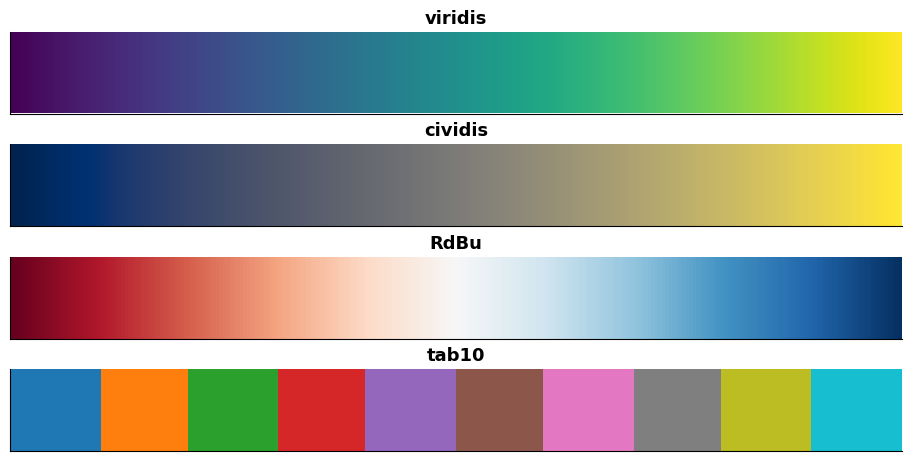

In [14]:
# Display a few palettes suitable for different data types.
gradient = np.linspace(0, 1, 256).reshape(1, -1)
palettes = ["viridis", "cividis", "RdBu", "tab10"]

fig, axes = plt.subplots(len(palettes), 1, figsize=(9, 4.5), layout="constrained")
for ax, cmap in zip(axes, palettes):
    ax.imshow(gradient, aspect="auto", cmap=cmap)
    ax.set(title=cmap, xticks=[], yticks=[])
plt.show()

General guidance:

- use a **sequential** colormap for low-to-high values;
- use a **diverging** colormap around a meaningful midpoint such as zero;
- use a **qualitative** palette for unordered categories;
- do not rely on color alone—also use labels, markers, line styles, or direct annotation;
- check whether the figure remains interpretable in grayscale.

## 13. Pie and donut charts—use sparingly

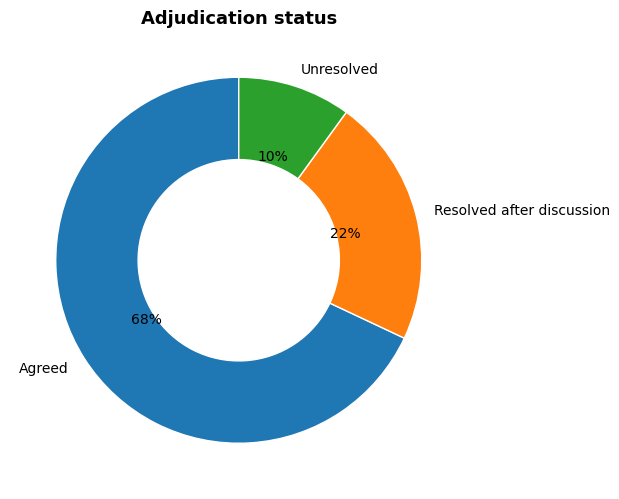

In [15]:
annotation_status = np.array([68, 22, 10])
status_labels = ["Agreed", "Resolved after discussion", "Unresolved"]

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.pie(
    annotation_status,
    labels=status_labels,
    autopct="%.0f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"},
)
ax.set_title("Adjudication status")
plt.show()

Pie charts are acceptable for a small number of parts that sum to a whole.  
For precise comparison, a sorted bar chart is usually clearer.

## 14. Saving publication-ready figures

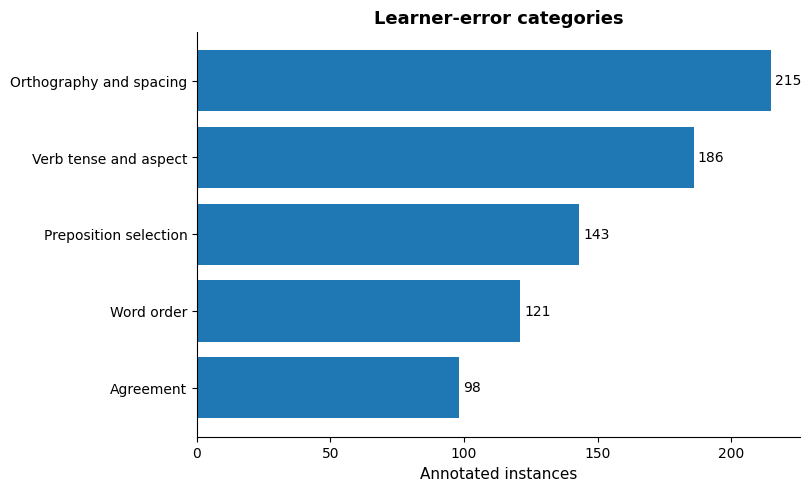

Saved to: /mnt/data/04_matplotlib/figures


In [16]:
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(error_types.index, error_types.values)
ax.set(title="Learner-error categories", xlabel="Annotated instances")
ax.bar_label(bars, padding=3)

# Raster format for slides/web.
fig.savefig(output_dir / "learner_errors.png", dpi=300, bbox_inches="tight")

# Vector formats for papers and later editing.
fig.savefig(output_dir / "learner_errors.svg", bbox_inches="tight")
fig.savefig(output_dir / "learner_errors.pdf", bbox_inches="tight")

plt.show()
print("Saved to:", output_dir.resolve())

Call `savefig` on the specific `Figure` object. A useful default is:

```python
fig.savefig("figure.png", dpi=300, bbox_inches="tight")
```

Use SVG or PDF when a journal or editing workflow benefits from vector graphics.

## 15. Reusable plotting functions

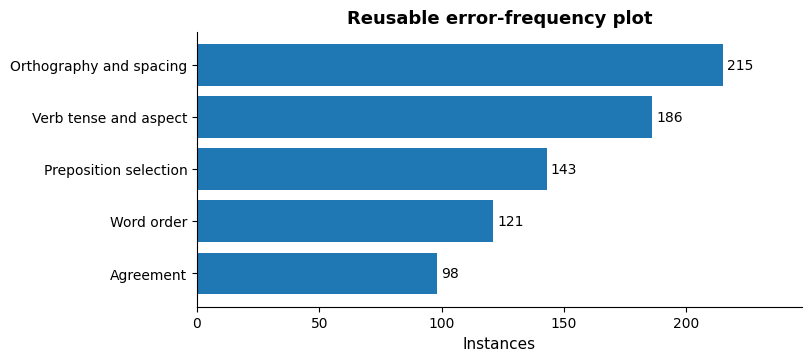

In [17]:
def plot_category_counts(
    counts: pd.Series,
    *,
    title: str,
    xlabel: str = "Count",
    top_n: int | None = None,
):
    """Plot a sorted horizontal bar chart and return Figure and Axes."""
    data = counts.sort_values(ascending=True)
    if top_n is not None:
        data = data.tail(top_n)

    fig, ax = plt.subplots(
        figsize=(8, max(3.5, 0.45 * len(data))),
        layout="constrained",
    )
    bars = ax.barh(data.index.astype(str), data.values)
    ax.bar_label(bars, padding=3)
    ax.set(title=title, xlabel=xlabel, ylabel="")
    ax.set_xlim(0, data.max() * 1.15)
    return fig, ax


fig, ax = plot_category_counts(
    error_types,
    title="Reusable error-frequency plot",
    xlabel="Instances",
)
plt.show()

Returning `fig, ax` lets callers customize or save the result without rewriting the function.

## 16. Common mistakes and fixes

| Problem | Why it happens | Better approach |
|---|---|---|
| Undefined `bar_width` | A variable was used before assignment | Define `width` next to the grouped-bar code |
| Bars hide one another | Multiple bars use identical x positions | Offset grouped bars or use stacking intentionally |
| Labels are clipped | Layout does not reserve enough space | Use `layout="constrained"` or `bbox_inches="tight"` |
| Categories are joined by lines | A line plot was chosen for nominal data | Use bars, dots, or a table |
| Too many colors | Color is used decoratively | Encode only meaningful categories or values |
| Unreadable x labels | Labels are long or numerous | Rotate, wrap, abbreviate, or use horizontal bars |
| Misleading y-axis | The chosen scale exaggerates or hides differences | Explain limits; bars should usually start at zero |
| Figure cannot be reproduced | Data and styling are scattered across cells | Put plotting logic in a function and set a seed |

## 17. Plotting pandas objects

pandas plotting methods are convenient wrappers around Matplotlib. They are useful for rapid exploration, but the returned object is still a Matplotlib `Axes`.

Two reliable patterns are:

```python
ax = dataframe.plot(...)
ax.set(...)
```

and, when a figure already exists:

```python
fig, ax = plt.subplots()
dataframe.plot(..., ax=ax)
```

Passing `ax=` makes the layout explicit and keeps pandas plots compatible with multi-panel figures and publication styling.


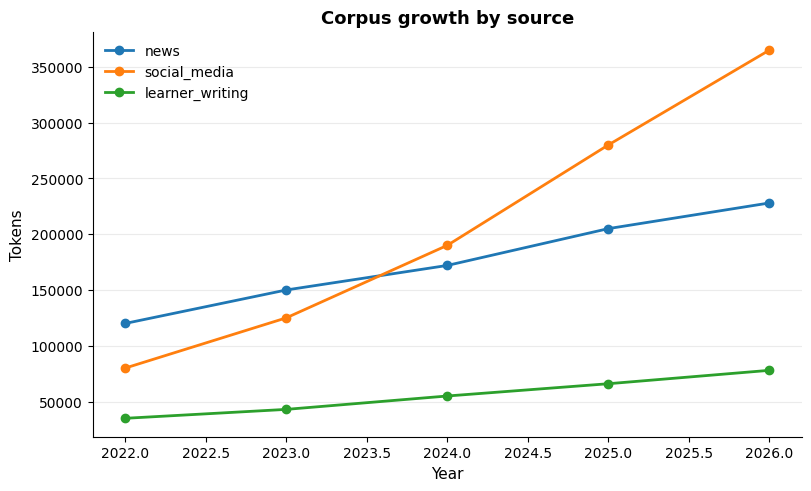

In [18]:
yearly_corpus = pd.DataFrame({
    "news": [120_000, 150_000, 172_000, 205_000, 228_000],
    "social_media": [80_000, 125_000, 190_000, 280_000, 365_000],
    "learner_writing": [35_000, 43_000, 55_000, 66_000, 78_000],
}, index=pd.Index([2022, 2023, 2024, 2025, 2026], name="year"))

fig, ax = plt.subplots(layout="constrained")
yearly_corpus.plot.line(marker="o", linewidth=2, ax=ax)
ax.set(
    title="Corpus growth by source",
    xlabel="Year",
    ylabel="Tokens",
)
ax.grid(axis="y", alpha=0.25)
plt.show()


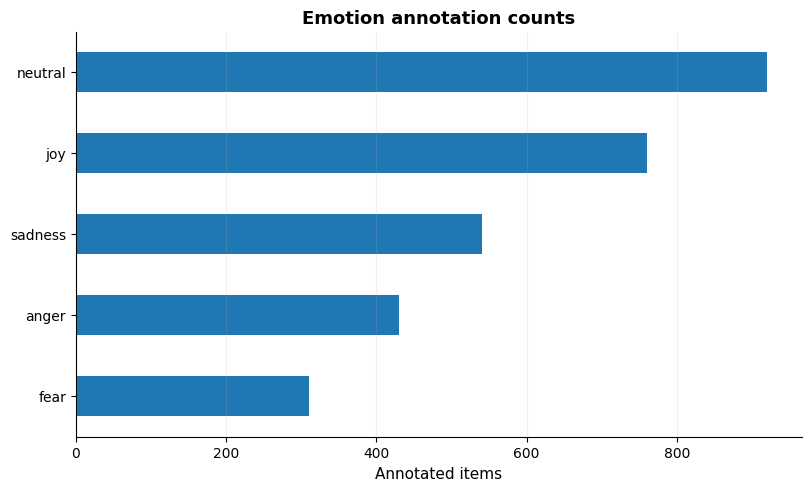

In [19]:
# A Series can be plotted directly. Sorting first improves readability.
annotation_counts = pd.Series({
    "joy": 760,
    "sadness": 540,
    "anger": 430,
    "fear": 310,
    "neutral": 920,
}).sort_values()

fig, ax = plt.subplots(layout="constrained")
annotation_counts.plot.barh(ax=ax)
ax.set(title="Emotion annotation counts", xlabel="Annotated items", ylabel="")
ax.grid(axis="x", alpha=0.2)
plt.show()


**When to use each interface**

- Use `Series.plot()` or `DataFrame.plot()` for quick exploration of tidy tabular data.
- Use explicit `ax.plot`, `ax.bar`, and related methods when you need precise control or reusable plotting functions.
- In research code, it is common to use pandas for data preparation and Matplotlib for the final figure.


## 18. Exercises

Complete these before opening the solution cells.

1. Plot the `yearly_corpus` DataFrame as a line chart using `DataFrame.plot()` and add markers, a title, and a y-axis grid.
2. Create a grouped bar chart comparing two models on accuracy, macro-F1, and weighted-F1.
3. Simulate 300 document lengths and show their distribution using both a histogram and a box plot in one figure.
4. Annotate the highest point in a five-year vocabulary-growth curve.
5. Write a function that receives a `pd.Series`, creates a sorted horizontal bar chart, and returns `fig, ax`.
6. Save one completed figure as both PNG at 300 DPI and SVG.


## 19. Reference solutions

These are complete runnable solutions. Try your own implementation first; visually different answers can still be correct.


### Solution 1 — pandas line plot


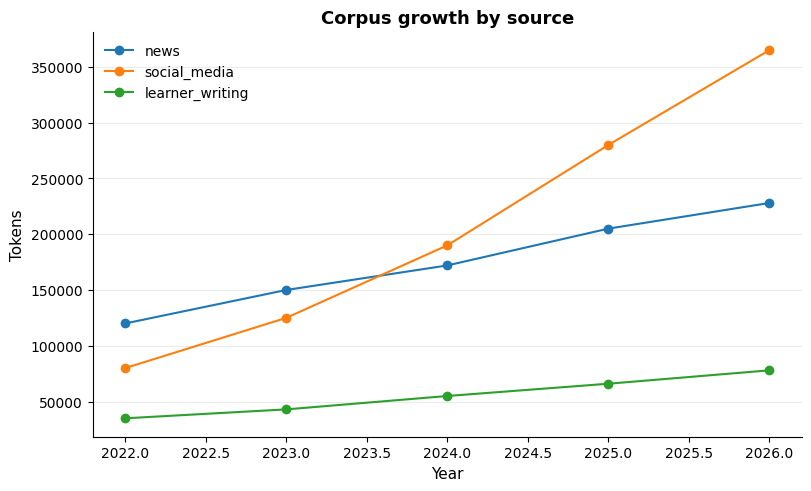

In [20]:
fig, ax = plt.subplots(layout="constrained")
yearly_corpus.plot(marker="o", ax=ax)
ax.set(title="Corpus growth by source", xlabel="Year", ylabel="Tokens")
ax.grid(axis="y", alpha=0.25)
plt.show()


### Solution 2 — grouped model comparison


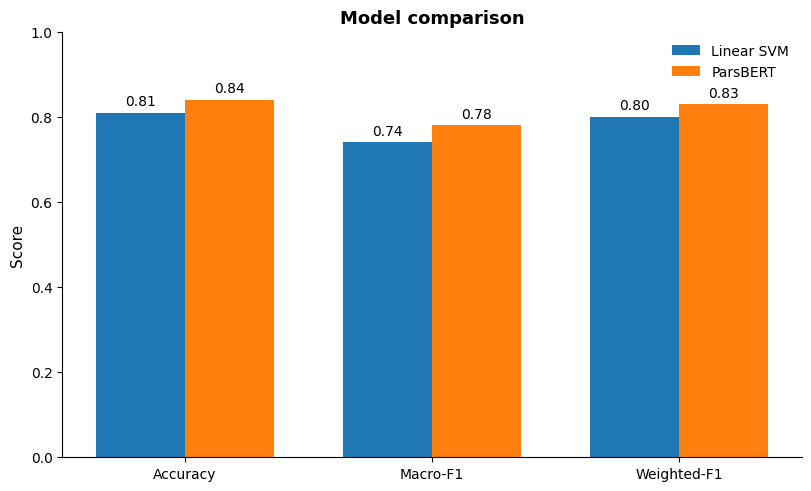

In [21]:
metrics = ["Accuracy", "Macro-F1", "Weighted-F1"]
model_a = np.array([0.81, 0.74, 0.80])
model_b = np.array([0.84, 0.78, 0.83])
x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(layout="constrained")
bars_a = ax.bar(x - width / 2, model_a, width, label="Linear SVM")
bars_b = ax.bar(x + width / 2, model_b, width, label="ParsBERT")
ax.bar_label(bars_a, fmt="%.2f", padding=3)
ax.bar_label(bars_b, fmt="%.2f", padding=3)
ax.set(title="Model comparison", ylabel="Score", xticks=x, xticklabels=metrics, ylim=(0, 1))
ax.legend()
plt.show()


### Solution 3 — histogram and box plot


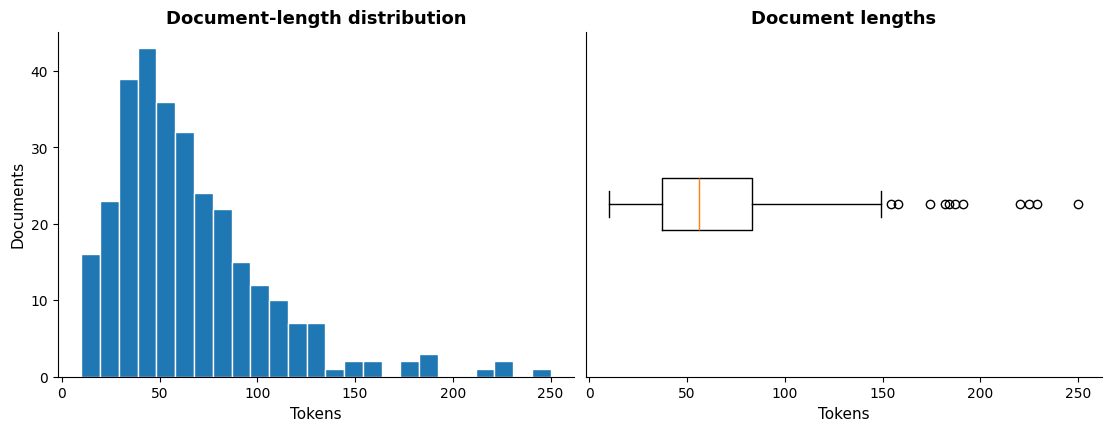

In [22]:
lengths = RNG.lognormal(mean=4.0, sigma=0.55, size=300).round().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
axes[0].hist(lengths, bins=25, edgecolor="white")
axes[0].set(title="Document-length distribution", xlabel="Tokens", ylabel="Documents")
axes[1].boxplot(lengths, vert=False)
axes[1].set(title="Document lengths", xlabel="Tokens", yticks=[])
plt.show()


### Solution 4 — annotate a maximum


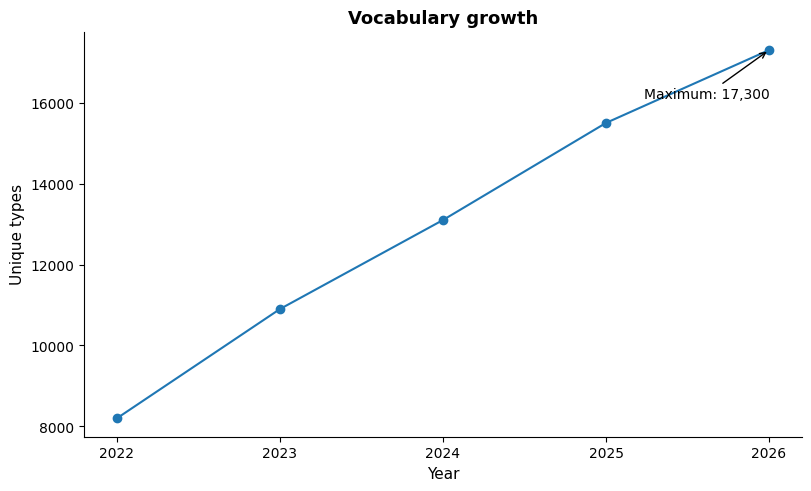

In [23]:
years = np.arange(2022, 2027)
vocabulary = np.array([8_200, 10_900, 13_100, 15_500, 17_300])
max_i = vocabulary.argmax()

fig, ax = plt.subplots(layout="constrained")
ax.plot(years, vocabulary, marker="o")
ax.annotate(
    f"Maximum: {vocabulary[max_i]:,}",
    xy=(years[max_i], vocabulary[max_i]),
    xytext=(-90, -35),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)
ax.set(title="Vocabulary growth", xlabel="Year", ylabel="Unique types", xticks=years)
plt.show()


### Solution 5 — reusable Series plotting function


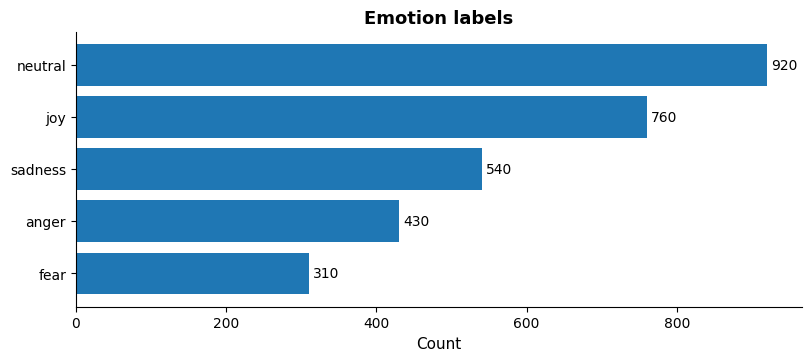

In [24]:
def plot_sorted_series(values: pd.Series, *, title: str, xlabel: str = "Count"):
    ordered = values.sort_values()
    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(ordered))), layout="constrained")
    bars = ax.barh(ordered.index.astype(str), ordered.to_numpy())
    ax.bar_label(bars, padding=3)
    ax.set(title=title, xlabel=xlabel, ylabel="")
    return fig, ax

fig, ax = plot_sorted_series(annotation_counts, title="Emotion labels")
plt.show()


### Solution 6 — export two formats


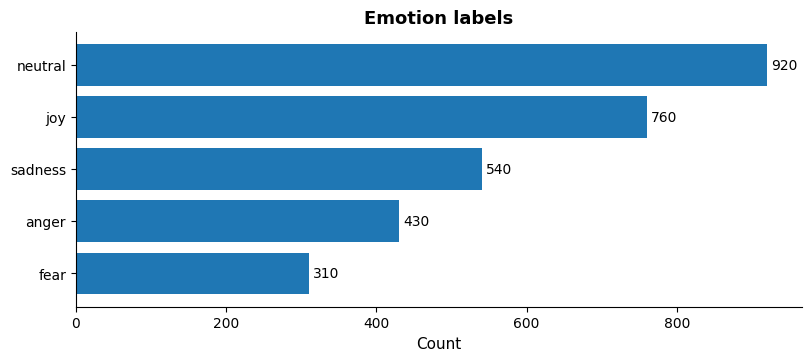

Saved: figures/emotion_labels.png
Saved: figures/emotion_labels.svg


In [25]:
exercise_output = Path("figures")
exercise_output.mkdir(exist_ok=True)

fig, ax = plot_sorted_series(annotation_counts, title="Emotion labels")
fig.savefig(exercise_output / "emotion_labels.png", dpi=300, bbox_inches="tight")
fig.savefig(exercise_output / "emotion_labels.svg", bbox_inches="tight")
plt.show()

print("Saved:", exercise_output / "emotion_labels.png")
print("Saved:", exercise_output / "emotion_labels.svg")


## 20. References

- Matplotlib quick start: https://matplotlib.org/stable/users/explain/quick_start.html
- Axes API: https://matplotlib.org/stable/api/axes_api.html
- pandas visualization: https://pandas.pydata.org/docs/user_guide/visualization.html
- Constrained layout: https://matplotlib.org/stable/users/explain/axes/constrainedlayout_guide.html
- Choosing colormaps: https://matplotlib.org/stable/users/explain/colors/colormaps.html
- Saving figures: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
